# 03 — Model Training & Evaluation
**Project:** Student Performance Predictor  
**Goal:** Train an XGBoost classifier to predict at-risk students 
using the final feature table built in Feature Engineering notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

In [3]:
feature = pd.read_csv("../data/processed/merged.csv")
feature

,code_module,code_presentation,id_student,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,at_risk,region_East Anglian Region,...,region_West Midlands Region,region_Yorkshire Region,mean_score,max_score,min_score,number_of_takes,mean_weight,total_clicks,num_active_days,avg_daily_clicks
0,AAA,2013J,11391,3,9,2,0,240,0,True,...,False,False,81.5,85.0,78.0,2.0,15.0,587.0,23.0,26.0
1,AAA,2013J,28400,3,2,1,0,60,0,False,...,False,False,69.0,70.0,68.0,2.0,15.0,821.0,36.0,23.0
2,AAA,2013J,30268,2,3,1,0,60,1,False,...,False,False,0.0,0.0,0.0,0.0,0.0,281.0,12.0,23.0
3,AAA,2013J,31604,2,5,1,0,60,0,False,...,False,False,71.5,72.0,71.0,2.0,15.0,992.0,51.0,19.0
4,AAA,2013J,32885,1,5,0,0,60,0,False,...,True,False,49.5,69.0,30.0,2.0,15.0,684.0,35.0,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32588,GGG,2014J,2640965,1,1,0,0,30,1,False,...,False,False,0.0,0.0,0.0,0.0,0.0,41.0,5.0,8.0
32589,GGG,2014J,2645731,1,4,1,0,30,0,True,...,False,False,80.0,80.0,80.0,1.0,0.0,81.0,8.0,10.0
32590,GGG,2014J,2648187,2,2,0,0,30,0,False,...,False,False,65.0,65.0,65.0,1.0,0.0,35.0,5.0,7.0
32591,GGG,2014J,2679821,1,9,1,0,30,1,False,...,False,False,83.0,83.0,83.0,1.0,0.0,267.0,11.0,24.0


In [4]:
feature.shape

(32593, 30)

In [5]:
feature.columns

Index(['code_module', 'code_presentation', 'id_student', 'highest_education',
       'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits',
       'at_risk', 'region_East Anglian Region', 'region_East Midlands Region',
       'region_Ireland', 'region_London Region', 'region_North Region',
       'region_North Western Region', 'region_Scotland',
       'region_South East Region', 'region_South Region',
       'region_South West Region', 'region_Wales',
       'region_West Midlands Region', 'region_Yorkshire Region', 'mean_score',
       'max_score', 'min_score', 'number_of_takes', 'mean_weight',
       'total_clicks', 'num_active_days', 'avg_daily_clicks'],
      dtype='str')

In [9]:
# SPLITTING MY DATA INTO X AND Y FOR MODEL TRAINING
X = feature.drop(columns= ["id_student", "code_presentation", "code_module", "at_risk"])
y = feature["at_risk"]

In [10]:
X.shape

(32593, 26)

In [11]:
X.columns

Index(['highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'region_East Anglian Region',
       'region_East Midlands Region', 'region_Ireland', 'region_London Region',
       'region_North Region', 'region_North Western Region', 'region_Scotland',
       'region_South East Region', 'region_South Region',
       'region_South West Region', 'region_Wales',
       'region_West Midlands Region', 'region_Yorkshire Region', 'mean_score',
       'max_score', 'min_score', 'number_of_takes', 'mean_weight',
       'total_clicks', 'num_active_days', 'avg_daily_clicks'],
      dtype='str')

In [12]:
y.shape

(32593,)

In [13]:
# SPLITTING INTO TRAINING AND TESTING DATA SETS

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 0, stratify= y)

In [15]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(26074, 26)
(6519, 26)
(26074,)
(6519,)


In [ ]:
# CREATING AND TRAINING THE MODEL

model = XGBClassifier(random_state= 42, eval_metric = "logloss")
model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [17]:
# MAKING PREDICTIONS

y_pred = model.predict(X_test)

In [18]:
print(f"classification_report : {classification_report(y_test, y_pred)}")

classification_report :               precision    recall  f1-score   support

           0       0.78      0.86      0.82      3077
           1       0.86      0.78      0.82      3442

    accuracy                           0.82      6519
   macro avg       0.82      0.82      0.82      6519
weighted avg       0.82      0.82      0.82      6519



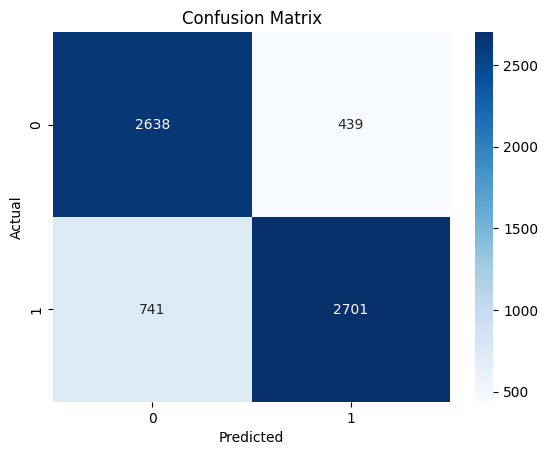

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.Figure(figsize=(6,4))
sns.heatmap(cm, annot= True, fmt= "d", cmap= "Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


What each number means:

2,638 (TN) — Safe students correctly identified as safe ✅
2,701 (TP) — At risk students correctly flagged ✅
439 (FP) — Safe students wrongly flagged as at risk ❌
741 (FN) — At risk students the model missed ❌


The most important number for your system is 741 — the False Negatives.
These are 741 at-risk students the model failed to catch. In a real university setting these students would receive no intervention and could fail or withdraw.
Reducing this number is your main goal in model improvement.

In [23]:
# LOADING MY TRAINED MODEL INTO THE MODELS FOLDER

import joblib
joblib.dump(model, "../models/xgb_model.pkl")
print("model saved")

model saved
